# Exploratory Data Analysis (EDA)




## Setup & Imports

In [1]:
# Add project root to path
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"✓ Project root added: {project_root}")

✓ Project root added: /home/brenda/final year project/PharmacyForecastingSystem


In [2]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import warnings

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Figure size defaults
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Packages imported successfully")

✓ Packages imported successfully


In [3]:
# Database connection
from config.database_config import DATABASE_URL

engine = create_engine(DATABASE_URL)
print("✓ Database connection established")

✓ Database connection established


## 1. DATA LOADING & OVERVIEW

In [4]:
# Load sales data with drug information
query = """
SELECT 
    sw.year,
    sw.week_number,
    sw.week_start_date,
    sw.week_end_date,
    sw.total_quantity,
    sw.avg_daily_quantity,
    d.drug_name,
    d.atc_code,
    d.drug_id
FROM raw_data.sales_weekly_raw sw
JOIN raw_data.drugs_raw d ON sw.drug_id = d.drug_id
ORDER BY sw.week_start_date, d.drug_name
"""

df = pd.read_sql_query(query, engine)

# Convert date columns to datetime
df['week_start_date'] = pd.to_datetime(df['week_start_date'])
df['week_end_date'] = pd.to_datetime(df['week_end_date'])

print(f"✓ Data loaded: {len(df):,} rows")
print(f"Date range: {df['week_start_date'].min()} to {df['week_start_date'].max()}")

✓ Data loaded: 2,380 rows
Date range: 2013-12-30 00:00:00 to 2019-10-07 00:00:00


In [5]:
# Dataset shape
print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

DATASET SHAPE
Rows: 2,380
Columns: 9
Memory usage: 0.37 MB


In [6]:
# Column names and data types
print("=" * 60)
print("COLUMN INFORMATION")
print("=" * 60)
print(df.dtypes)
print("\n")
df.info()

COLUMN INFORMATION
year                           int64
week_number                    int64
week_start_date       datetime64[ns]
week_end_date         datetime64[ns]
total_quantity                 int64
avg_daily_quantity           float64
drug_name                     object
atc_code                      object
drug_id                        int64
dtype: object


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2380 entries, 0 to 2379
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   year                2380 non-null   int64         
 1   week_number         2380 non-null   int64         
 2   week_start_date     2380 non-null   datetime64[ns]
 3   week_end_date       2380 non-null   datetime64[ns]
 4   total_quantity      2380 non-null   int64         
 5   avg_daily_quantity  2380 non-null   float64       
 6   drug_name           2380 non-null   object        
 7   atc_code         

In [7]:
# First and last rows
print("=" * 60)
print("FIRST 10 ROWS")
print("=" * 60)
display(df.head(10))

print("\n" + "=" * 60)
print("LAST 10 ROWS")
print("=" * 60)
display(df.tail(10))

FIRST 10 ROWS


,year,week_number,week_start_date,week_end_date,total_quantity,avg_daily_quantity,drug_name,atc_code,drug_id
0,2014,1,2013-12-30,2014-01-05,14,2.00,M01AB,M01AB,1
1,2014,1,2013-12-30,2014-01-05,11,1.67,M01AE,M01AE,2
2,2014,1,2013-12-30,2014-01-05,21,3.04,N02BA,N02BA,3
3,2014,1,2013-12-30,2014-01-05,185,26.56,N02BE,N02BE,4
4,2014,1,2013-12-30,2014-01-05,41,5.86,N05B,N05B,5
5,2014,1,2013-12-30,2014-01-05,32,4.57,R03,R03,7
6,2014,1,2013-12-30,2014-01-05,7,1.00,R06,R06,8
7,2014,2,2014-01-06,2014-01-12,29,4.19,M01AB,M01AB,1
8,2014,2,2014-01-06,2014-01-12,12,1.81,M01AE,M01AE,2
9,2014,2,2014-01-06,2014-01-12,37,5.41,N02BA,N02BA,3



LAST 10 ROWS


,year,week_number,week_start_date,week_end_date,total_quantity,avg_daily_quantity,drug_name,atc_code,drug_id
2370,2019,40,2019-09-30,2019-10-06,30,4.29,R03,R03,7
2371,2019,40,2019-09-30,2019-10-06,12,1.73,R06,R06,8
2372,2019,41,2019-10-07,2019-10-13,7,1.10,M01AB,M01AB,1
2373,2019,41,2019-10-07,2019-10-13,6,0.89,M01AE,M01AE,2
2374,2019,41,2019-10-07,2019-10-13,3,0.50,N02BA,N02BA,3
2375,2019,41,2019-10-07,2019-10-13,95,13.59,N02BE,N02BE,4
2376,2019,41,2019-10-07,2019-10-13,26,3.71,N05B,N05B,5
2377,2019,41,2019-10-07,2019-10-13,2,0.29,N05C,N05C,6
2378,2019,41,2019-10-07,2019-10-13,12,1.71,R03,R03,7
2379,2019,41,2019-10-07,2019-10-13,1,0.14,R06,R06,8


## 2. MISSING DATA ANALYSIS

In [8]:
# Missing values count
print("=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)

missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).values
})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_data) > 0:
    display(missing_data)
else:
    print("✓ No missing values found!")

MISSING VALUES ANALYSIS
✓ No missing values found!


## 3. DATA QUALITY CHECKS

In [10]:
print("=" * 60)
print("DATA QUALITY CHECKS")
print("=" * 60)

# Duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates:,}")

# Duplicate key check (year, week, drug)
key_duplicates = df.duplicated(subset=['year', 'week_number', 'drug_id']).sum()
print(f"Duplicate keys (year, week, drug): {key_duplicates:,}")

# Negative values
negative_qty = (df['total_quantity'] < 0).sum()
print(f"Negative quantities: {negative_qty:,}")

# Zero values
zero_qty = (df['total_quantity'] == 0).sum()
print(f"Zero quantities: {zero_qty:,} ({zero_qty/len(df)*100:.2f}%)")

# Invalid dates (future dates)
today = pd.Timestamp.now()
future_dates = (df['week_start_date'] > today).sum()
print(f"Future dates: {future_dates:,}")

# Date consistency (week_end = week_start + 6 days)
date_diff = (df['week_end_date'] - df['week_start_date']).dt.days
invalid_weeks = (date_diff != 6).sum()
print(f"Invalid week ranges (not 7 days): {invalid_weeks:,}")

DATA QUALITY CHECKS
Duplicate rows: 0
Duplicate keys (year, week, drug): 0
Negative quantities: 0
Zero quantities: 0 (0.00%)
Future dates: 0
Invalid week ranges (not 7 days): 0


## 4. DESCRIPTIVE STATISTICS

In [11]:
# Numerical summary
print("=" * 60)
print("NUMERICAL VARIABLES SUMMARY")
print("=" * 60)
display(df.describe())

NUMERICAL VARIABLES SUMMARY


,year,week_number,week_start_date,week_end_date,total_quantity,avg_daily_quantity,drug_id
count,2380.000000,2380.000000,2380,2380,2380.000000,2380.000000,2380.000000
mean,2016.401681,25.903782,2016-11-17 02:15:31.764705792,2016-11-23 02:15:31.764705792,53.332773,7.658752,4.477311
min,2014.000000,1.000000,2013-12-30 00:00:00,2014-01-05 00:00:00,1.000000,0.140000,1.000000
25%,2015.000000,13.000000,2015-06-06 06:00:00,2015-06-12 06:00:00,19.000000,2.817500,2.000000
50%,2016.000000,26.000000,2016-11-14 00:00:00,2016-11-20 00:00:00,31.000000,4.430000,4.000000
75%,2018.000000,38.000000,2018-05-07 00:00:00,2018-05-13 00:00:00,51.250000,7.392500,7.000000
max,2019.000000,53.000000,2019-10-07 00:00:00,2019-10-13 00:00:00,546.000000,78.130000,8.000000
std,1.673922,14.812304,NaN,NaN,67.922459,9.712329,2.301541


In [12]:
# Detailed statistics for key columns
print("=" * 60)
print("QUANTITY STATISTICS")
print("=" * 60)

qty_stats = pd.DataFrame({
    'Metric': ['Mean', 'Median', 'Std Dev', 'Min', 'Max', 'Skewness', 'Kurtosis', 'Q1', 'Q3', 'IQR'],
    'total_quantity': [
        df['total_quantity'].mean(),
        df['total_quantity'].median(),
        df['total_quantity'].std(),
        df['total_quantity'].min(),
        df['total_quantity'].max(),
        df['total_quantity'].skew(),
        df['total_quantity'].kurtosis(),
        df['total_quantity'].quantile(0.25),
        df['total_quantity'].quantile(0.75),
        df['total_quantity'].quantile(0.75) - df['total_quantity'].quantile(0.25)
    ]
})

display(qty_stats)

QUANTITY STATISTICS


,Metric,total_quantity
0,Mean,53.332773
1,Median,31.000000
2,Std Dev,67.922459
3,Min,1.000000
4,Max,546.000000
5,Skewness,2.664507
6,Kurtosis,7.646756
7,Q1,19.000000
8,Q3,51.250000
9,IQR,32.250000


In [13]:
# Categorical variables summary
print("=" * 60)
print("CATEGORICAL VARIABLES SUMMARY")
print("=" * 60)

print(f"Unique drugs: {df['drug_name'].nunique()}")
print(f"Unique ATC codes: {df['atc_code'].nunique()}")
print(f"Unique years: {df['year'].nunique()}")
print(f"Date range: {df['week_start_date'].min()} to {df['week_start_date'].max()}")
print(f"Total weeks: {df[['year', 'week_number']].drop_duplicates().shape[0]}")

CATEGORICAL VARIABLES SUMMARY
Unique drugs: 8
Unique ATC codes: 8
Unique years: 6
Date range: 2013-12-30 00:00:00 to 2019-10-07 00:00:00
Total weeks: 302


## 5. UNIVARIATE ANALYSIS

### 5.1 Numerical Variables

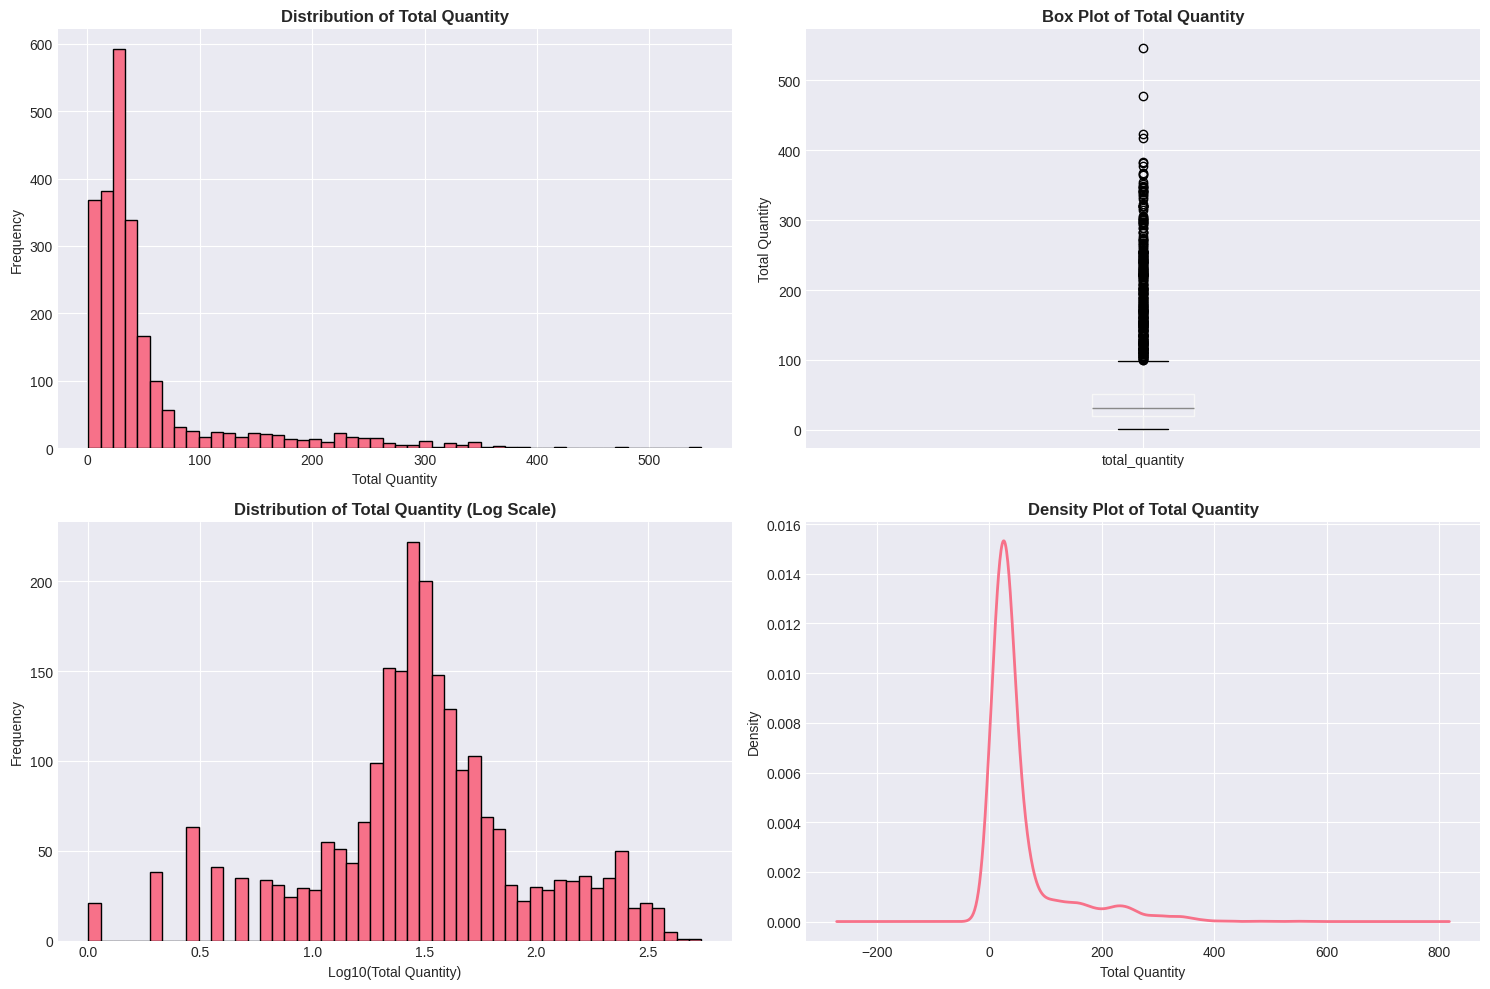

In [14]:
# Distribution plots for total_quantity
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram
df['total_quantity'].hist(bins=50, ax=axes[0, 0], edgecolor='black')
axes[0, 0].set_title('Distribution of Total Quantity', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Total Quantity')
axes[0, 0].set_ylabel('Frequency')

# Box plot
df.boxplot(column='total_quantity', ax=axes[0, 1])
axes[0, 1].set_title('Box Plot of Total Quantity', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Total Quantity')

# Log scale histogram (if positive values)
if df['total_quantity'].min() > 0:
    df['total_quantity'].apply(np.log10).hist(bins=50, ax=axes[1, 0], edgecolor='black')
    axes[1, 0].set_title('Distribution of Total Quantity (Log Scale)', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Log10(Total Quantity)')
    axes[1, 0].set_ylabel('Frequency')

# Density plot
df['total_quantity'].plot(kind='density', ax=axes[1, 1], linewidth=2)
axes[1, 1].set_title('Density Plot of Total Quantity', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Total Quantity')

plt.tight_layout()
plt.show()

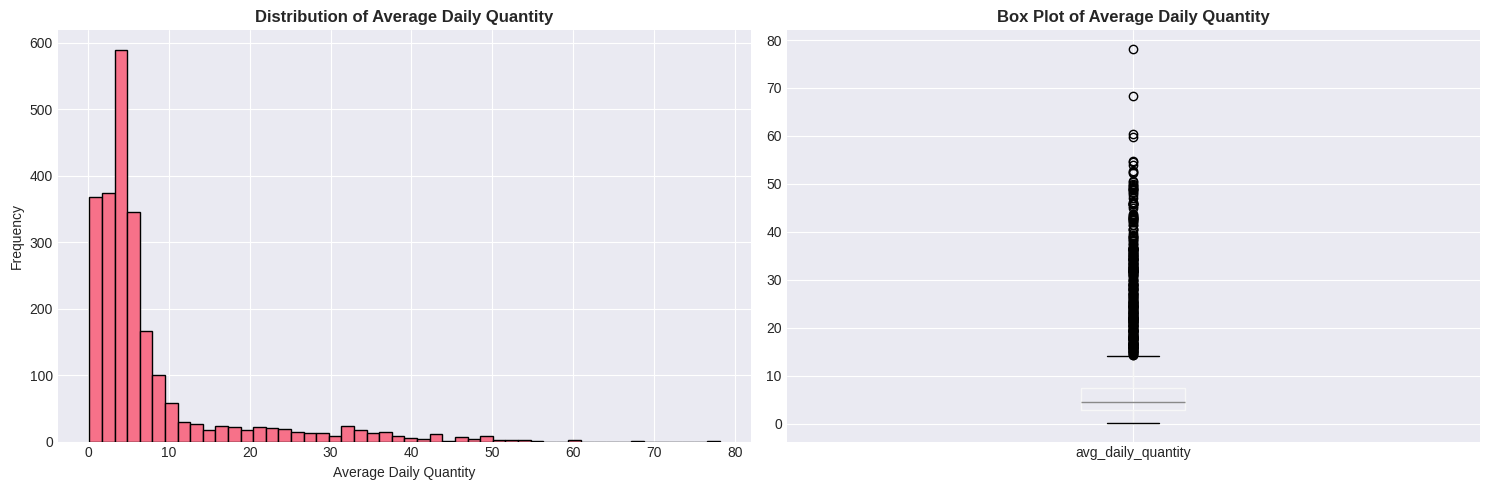

In [15]:
# Average daily quantity distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df['avg_daily_quantity'].hist(bins=50, ax=axes[0], edgecolor='black')
axes[0].set_title('Distribution of Average Daily Quantity', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Average Daily Quantity')
axes[0].set_ylabel('Frequency')

df.boxplot(column='avg_daily_quantity', ax=axes[1])
axes[1].set_title('Box Plot of Average Daily Quantity', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 5.2 Categorical Variables

TOP 20 DRUGS BY NUMBER OF RECORDS
drug_name
M01AB    302
M01AE    302
N02BA    302
N02BE    302
N05B     302
R03      302
R06      302
N05C     266
Name: count, dtype: int64


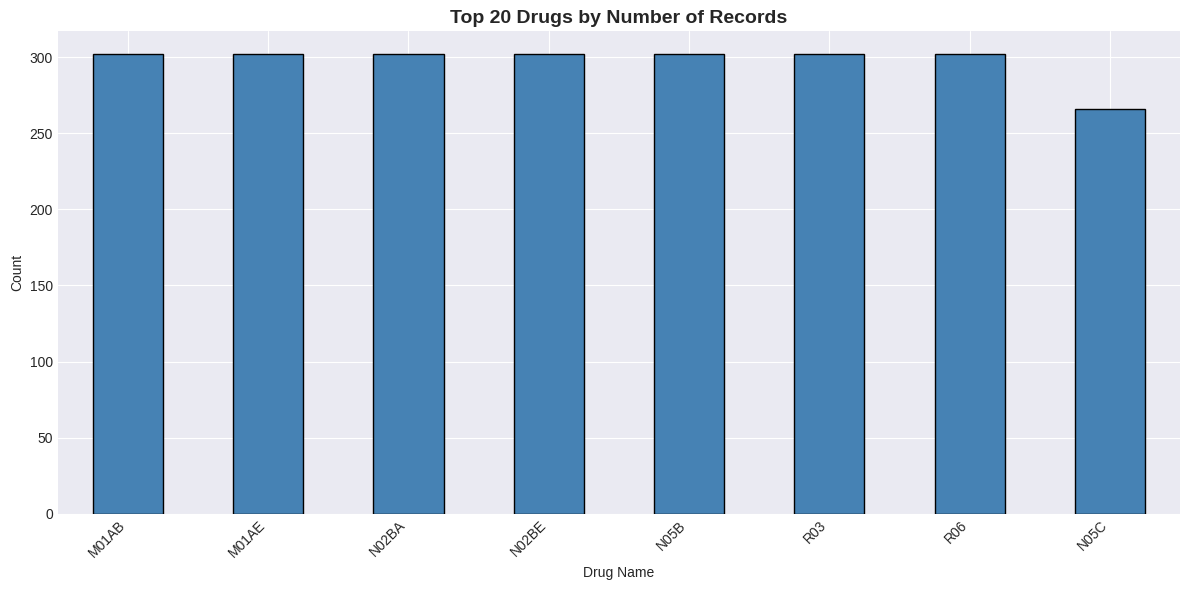

In [16]:
# Top 20 drugs by frequency
print("=" * 60)
print("TOP 20 DRUGS BY NUMBER OF RECORDS")
print("=" * 60)

top_drugs_freq = df['drug_name'].value_counts().head(20)
print(top_drugs_freq)

# Visualize
plt.figure(figsize=(12, 6))
top_drugs_freq.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 20 Drugs by Number of Records', fontsize=14, fontweight='bold')
plt.xlabel('Drug Name')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

ATC CODE DISTRIBUTION
atc_code
M01AB    302
M01AE    302
N02BA    302
N02BE    302
N05B     302
R03      302
R06      302
N05C     266
Name: count, dtype: int64


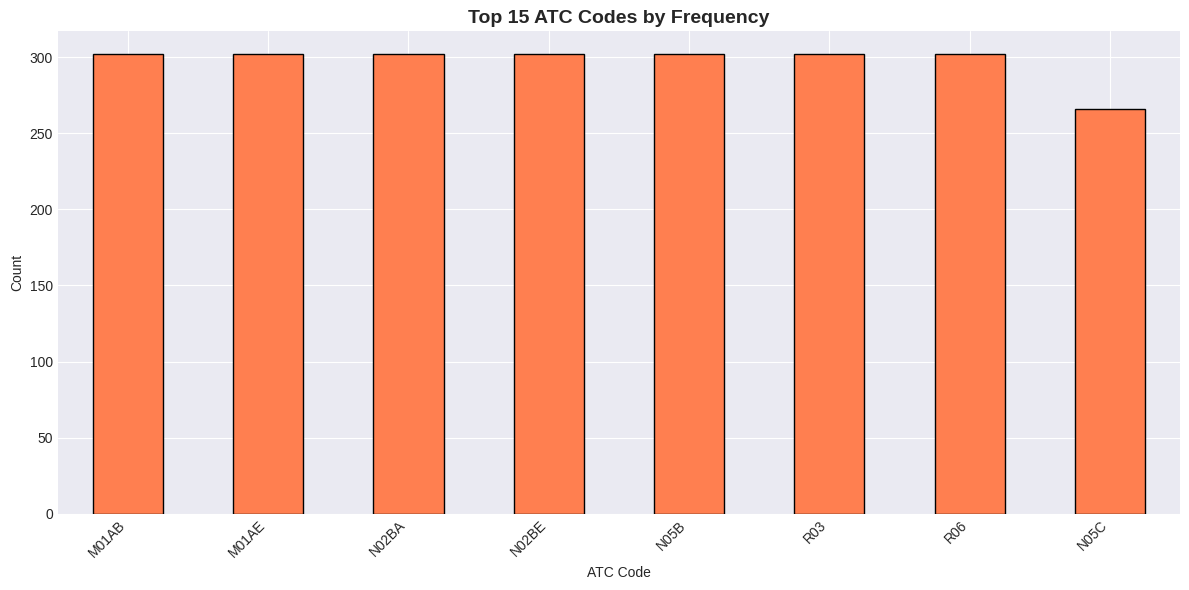

In [17]:
# ATC code distribution
print("=" * 60)
print("ATC CODE DISTRIBUTION")
print("=" * 60)

atc_counts = df['atc_code'].value_counts().head(15)
print(atc_counts)

plt.figure(figsize=(12, 6))
atc_counts.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Top 15 ATC Codes by Frequency', fontsize=14, fontweight='bold')
plt.xlabel('ATC Code')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5.3 Temporal Variables

RECORDS PER YEAR
year
2014    414
2015    417
2016    409
2017    406
2018    407
2019    327
Name: count, dtype: int64


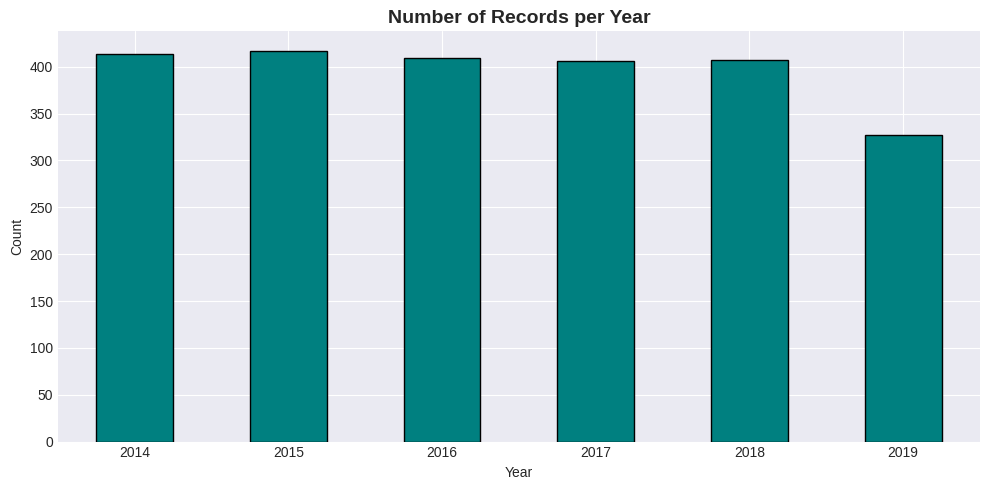

In [18]:
# Records per year
print("=" * 60)
print("RECORDS PER YEAR")
print("=" * 60)

year_counts = df['year'].value_counts().sort_index()
print(year_counts)

plt.figure(figsize=(10, 5))
year_counts.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Number of Records per Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [19]:
# Check for missing weeks
print("=" * 60)
print("TIME CONTINUITY CHECK")
print("=" * 60)

# Get all unique week_start_dates
all_weeks = df['week_start_date'].drop_duplicates().sort_values()
date_range = pd.date_range(start=all_weeks.min(), end=all_weeks.max(), freq='W-MON')

missing_weeks = set(date_range) - set(all_weeks)

if len(missing_weeks) > 0:
    print(f"⚠ Missing weeks detected: {len(missing_weeks)}")
    print("\nFirst 10 missing weeks:")
    for week in sorted(list(missing_weeks))[:10]:
        print(f"  - {week.date()}")
else:
    print("✓ No missing weeks detected")

TIME CONTINUITY CHECK
✓ No missing weeks detected


## 6. BIVARIATE ANALYSIS

### 6.1 Correlation Analysis

CORRELATION MATRIX


,year,week_number,total_quantity,avg_daily_quantity
year,1.000000,-0.081680,0.007464,0.007662
week_number,-0.081680,1.000000,-0.009570,-0.009686
total_quantity,0.007464,-0.009570,1.000000,0.999990
avg_daily_quantity,0.007662,-0.009686,0.999990,1.000000


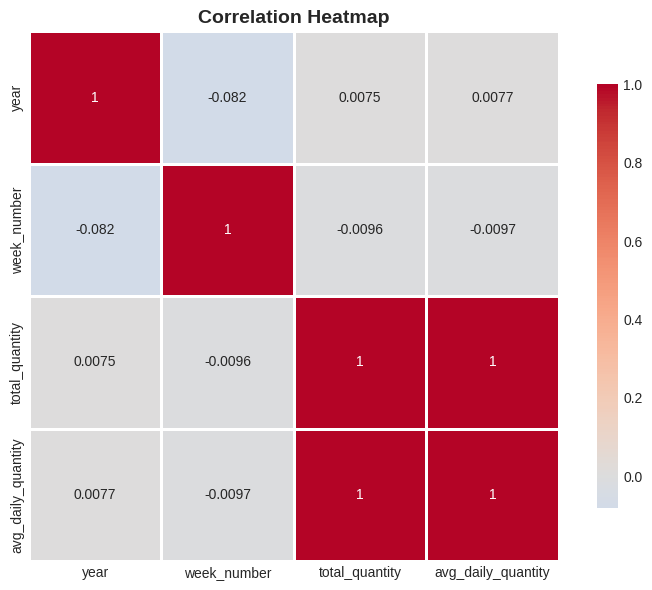

In [20]:
# Correlation matrix
numerical_cols = ['year', 'week_number', 'total_quantity', 'avg_daily_quantity']
correlation_matrix = df[numerical_cols].corr()

print("=" * 60)
print("CORRELATION MATRIX")
print("=" * 60)
display(correlation_matrix)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 Sales by Drug

TOP 20 DRUGS BY TOTAL SALES
drug_name
N02BE    62859
N05B     18631
R03      11604
M01AB    10460
M01AE     8058
N02BA     8039
R06       6035
N05C      1246
Name: total_quantity, dtype: int64


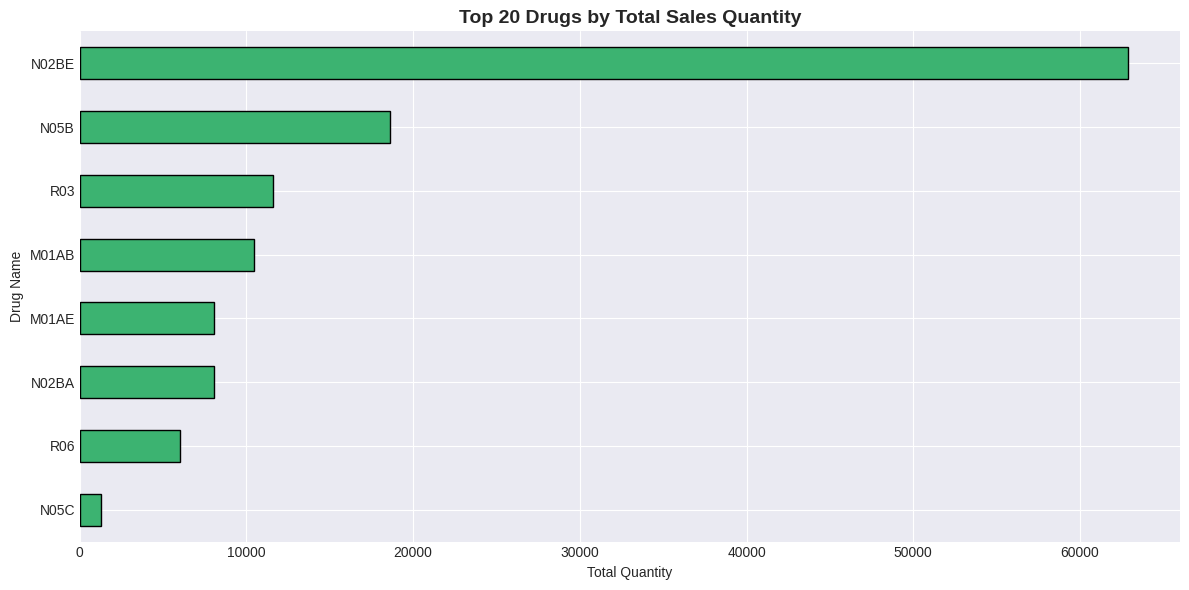

In [21]:
# Top 20 drugs by total sales
print("=" * 60)
print("TOP 20 DRUGS BY TOTAL SALES")
print("=" * 60)

top_drugs_sales = df.groupby('drug_name')['total_quantity'].sum().sort_values(ascending=False).head(20)
print(top_drugs_sales)

plt.figure(figsize=(12, 6))
top_drugs_sales.plot(kind='barh', color='mediumseagreen', edgecolor='black')
plt.title('Top 20 Drugs by Total Sales Quantity', fontsize=14, fontweight='bold')
plt.xlabel('Total Quantity')
plt.ylabel('Drug Name')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [22]:
# Drug statistics (mean, std, cv)
print("=" * 60)
print("DRUG SALES STATISTICS (Top 10)")
print("=" * 60)

drug_stats = df.groupby('drug_name')['total_quantity'].agg(['sum', 'mean', 'std', 'count'])
drug_stats['cv'] = (drug_stats['std'] / drug_stats['mean']) * 100  # Coefficient of variation
drug_stats = drug_stats.sort_values('sum', ascending=False).head(10)

display(drug_stats)

DRUG SALES STATISTICS (Top 10)


,sum,mean,std,count,cv
drug_name,,,,,
N02BE,62859,208.142384,76.074646,302,36.549330
N05B,18631,61.692053,22.401824,302,36.312334
R03,11604,38.423841,22.899299,302,59.596590
M01AB,10460,34.635762,8.579883,302,24.771747
M01AE,8058,26.682119,7.071416,302,26.502454
N02BA,8039,26.619205,8.070538,302,30.318478
R06,6035,19.983444,11.312669,302,56.610205
N05C,1246,4.684211,2.905735,266,62.032549


### 6.3 Sales by ATC Code

TOP 15 ATC CODES BY TOTAL SALES
atc_code
N02BE    62859
N05B     18631
R03      11604
M01AB    10460
M01AE     8058
N02BA     8039
R06       6035
N05C      1246
Name: total_quantity, dtype: int64


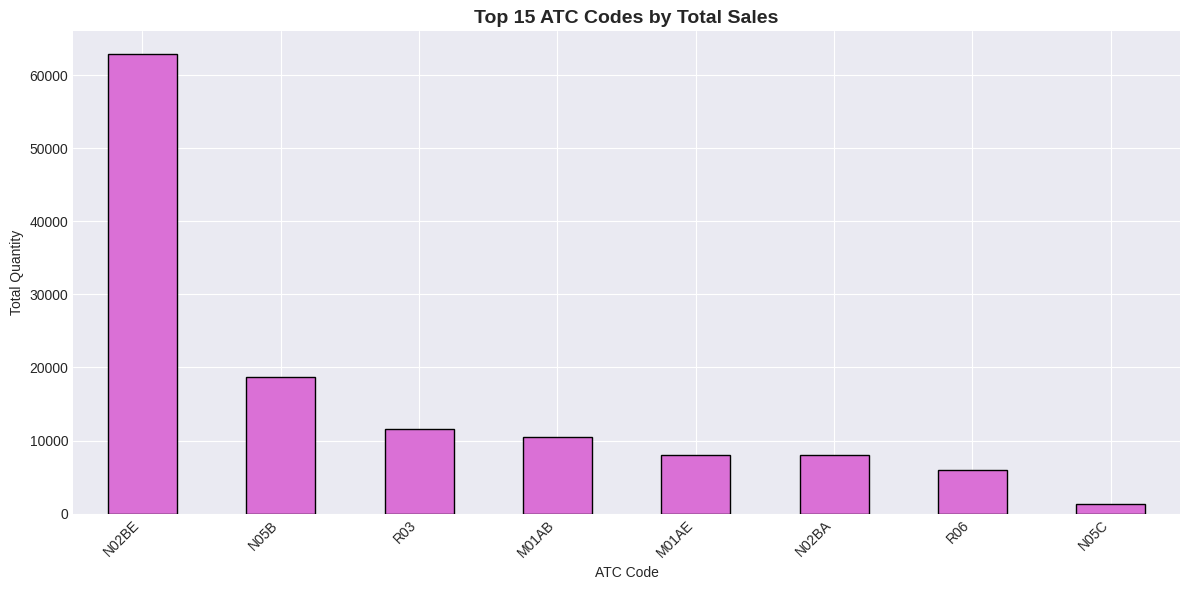

In [23]:
# Sales by ATC code
print("=" * 60)
print("TOP 15 ATC CODES BY TOTAL SALES")
print("=" * 60)

atc_sales = df.groupby('atc_code')['total_quantity'].sum().sort_values(ascending=False).head(15)
print(atc_sales)

plt.figure(figsize=(12, 6))
atc_sales.plot(kind='bar', color='orchid', edgecolor='black')
plt.title('Top 15 ATC Codes by Total Sales', fontsize=14, fontweight='bold')
plt.xlabel('ATC Code')
plt.ylabel('Total Quantity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 6.4 Time Series Analysis

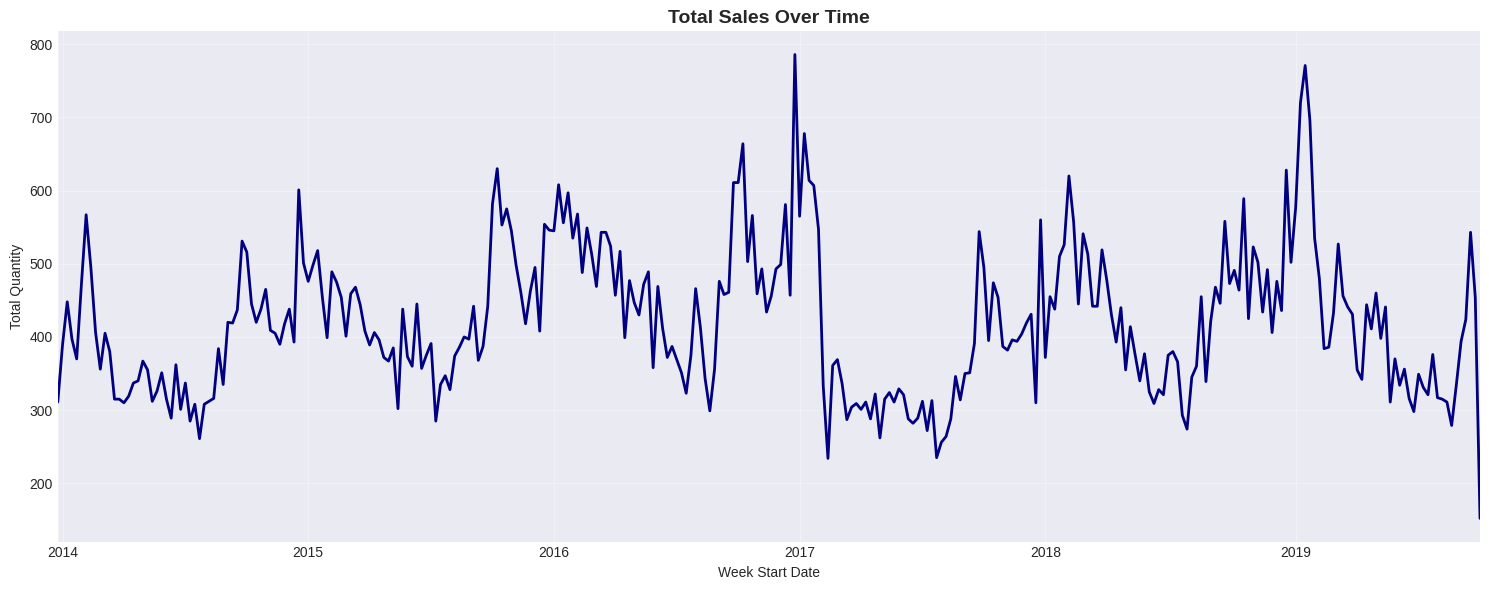

In [24]:
# Total sales over time
weekly_sales = df.groupby('week_start_date')['total_quantity'].sum().sort_index()

plt.figure(figsize=(15, 6))
weekly_sales.plot(linewidth=2, color='navy')
plt.title('Total Sales Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Week Start Date')
plt.ylabel('Total Quantity')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

TOTAL SALES BY YEAR
year
2014    19901
2015    23018
2016    25027
2017    19224
2018    22685
2019    17077
Name: total_quantity, dtype: int64


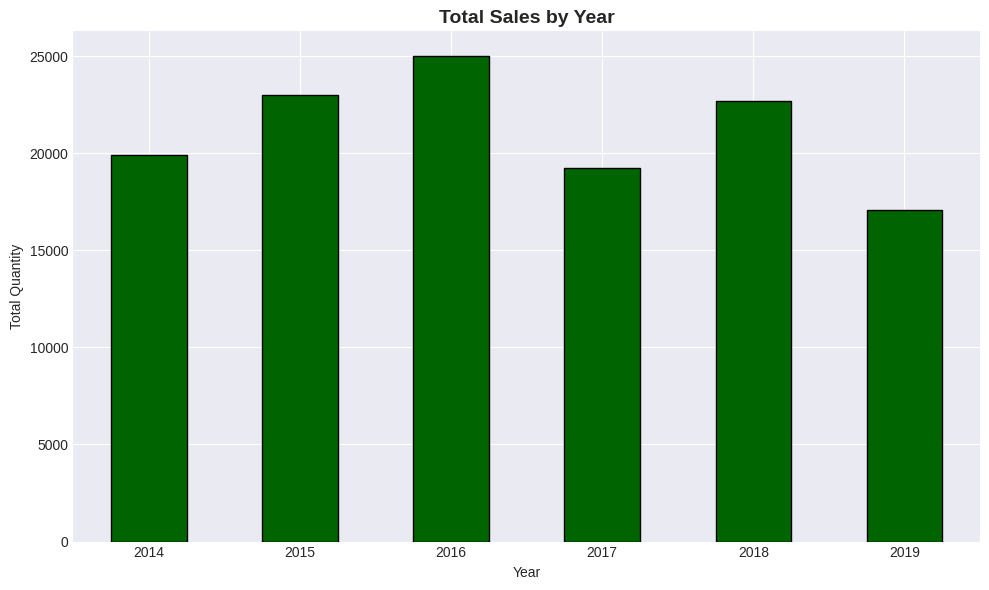

In [25]:
# Sales by year
yearly_sales = df.groupby('year')['total_quantity'].sum().sort_index()

print("=" * 60)
print("TOTAL SALES BY YEAR")
print("=" * 60)
print(yearly_sales)

plt.figure(figsize=(10, 6))
yearly_sales.plot(kind='bar', color='darkgreen', edgecolor='black')
plt.title('Total Sales by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Quantity')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

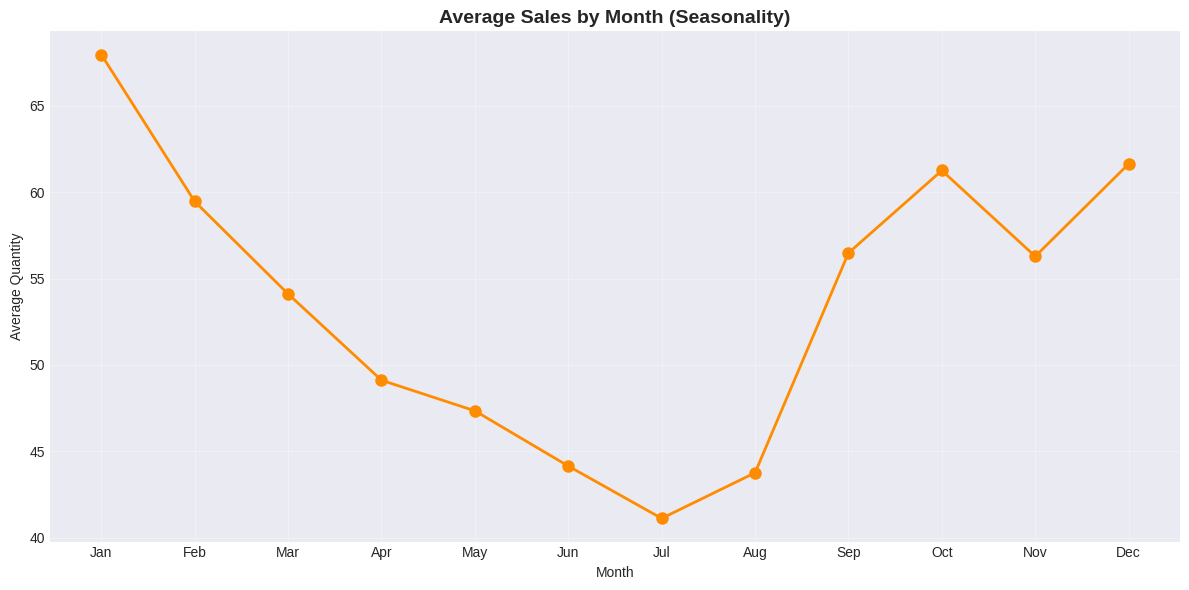

In [26]:
# Average sales by week number (seasonality check)
df['month'] = df['week_start_date'].dt.month
monthly_avg = df.groupby('month')['total_quantity'].mean().sort_index()

plt.figure(figsize=(12, 6))
monthly_avg.plot(kind='line', marker='o', linewidth=2, markersize=8, color='darkorange')
plt.title('Average Sales by Month (Seasonality)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Quantity')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. MULTIVARIATE ANALYSIS

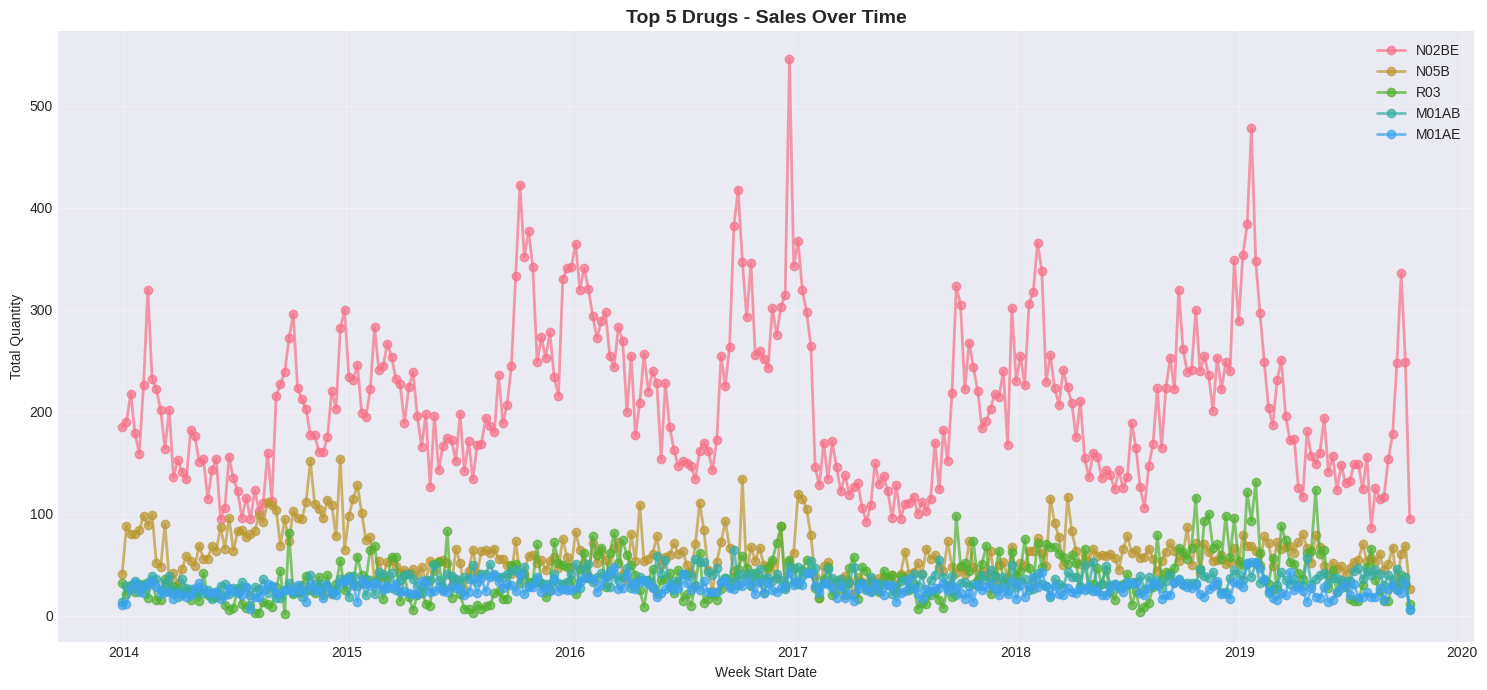

In [27]:
# Top 5 drugs over time
top_5_drugs = df.groupby('drug_name')['total_quantity'].sum().nlargest(5).index

plt.figure(figsize=(15, 7))
for drug in top_5_drugs:
    drug_data = df[df['drug_name'] == drug].groupby('week_start_date')['total_quantity'].sum()
    plt.plot(drug_data.index, drug_data.values, marker='o', linewidth=2, label=drug, alpha=0.7)

plt.title('Top 5 Drugs - Sales Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Week Start Date')
plt.ylabel('Total Quantity')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

PIVOT TABLE: YEAR vs TOP 10 DRUGS


drug_name,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
year,,,,,,,,
2014,1413,1219,1585,9115,4277,268,1238,786
2015,1894,1492,1597,12138,3001,164,1748,984
2016,2077,1559,1630,13231,3142,207,2133,1048
2017,1815,1360,1265,9207,2543,176,1884,974
2018,1753,1359,1096,11160,3256,235,2649,1177
2019,1508,1069,866,8008,2412,196,1952,1066


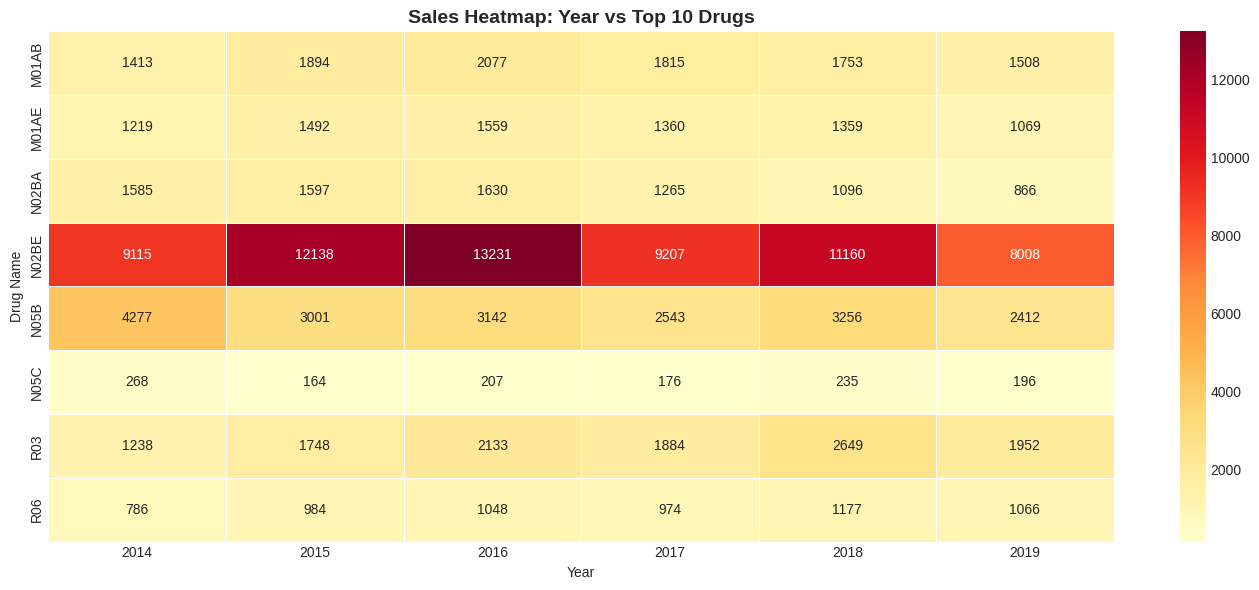

In [28]:
# Pivot table: Year vs Top 10 Drugs
top_10_drugs = df.groupby('drug_name')['total_quantity'].sum().nlargest(10).index
pivot_data = df[df['drug_name'].isin(top_10_drugs)].pivot_table(
    values='total_quantity',
    index='year',
    columns='drug_name',
    aggfunc='sum',
    fill_value=0
)

print("=" * 60)
print("PIVOT TABLE: YEAR vs TOP 10 DRUGS")
print("=" * 60)
display(pivot_data)

# Heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(pivot_data.T, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Sales Heatmap: Year vs Top 10 Drugs', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Drug Name')
plt.tight_layout()
plt.show()

## 8. OUTLIER DETECTION

In [29]:
# IQR method for outlier detection
print("=" * 60)
print("OUTLIER DETECTION (IQR METHOD)")
print("=" * 60)

Q1 = df['total_quantity'].quantile(0.25)
Q3 = df['total_quantity'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['total_quantity'] < lower_bound) | (df['total_quantity'] > upper_bound)]

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")
print(f"\nOutliers detected: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")

if len(outliers) > 0:
    print("\nTop 10 outliers:")
    display(outliers.nlargest(10, 'total_quantity')[['drug_name', 'week_start_date', 'total_quantity']])

OUTLIER DETECTION (IQR METHOD)
Q1: 19.00
Q3: 51.25
IQR: 32.25
Lower Bound: -29.38
Upper Bound: 99.62

Outliers detected: 321 (13.49%)

Top 10 outliers:


,drug_name,week_start_date,total_quantity
1235,N02BE,2016-12-26,546
2080,N02BE,2019-01-21,478
738,N02BE,2015-10-12,423
1139,N02BE,2016-10-03,418
2072,N02BE,2019-01-14,384
1131,N02BE,2016-09-26,382
754,N02BE,2015-10-26,377
1251,N02BE,2017-01-09,368
1687,N02BE,2018-02-05,366
842,N02BE,2016-01-11,365


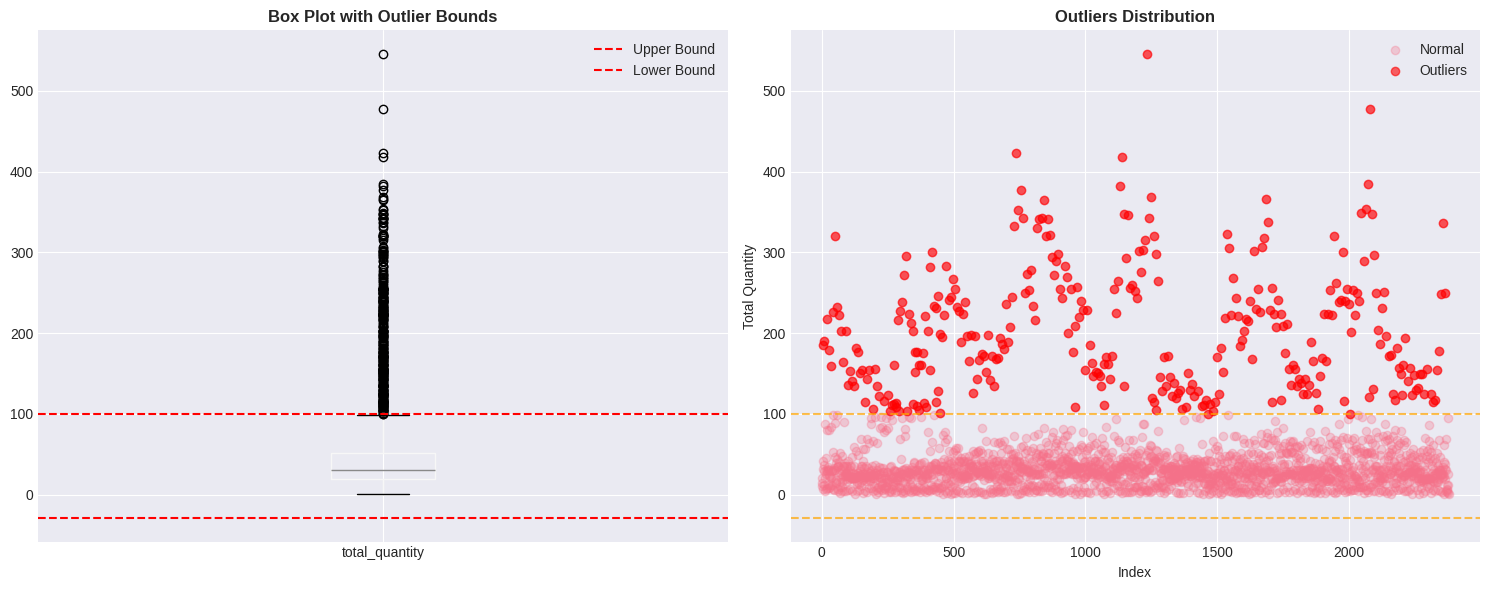

In [30]:
# Visualize outliers
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Box plot with outliers highlighted
df.boxplot(column='total_quantity', ax=axes[0])
axes[0].axhline(y=upper_bound, color='r', linestyle='--', label='Upper Bound')
axes[0].axhline(y=lower_bound, color='r', linestyle='--', label='Lower Bound')
axes[0].set_title('Box Plot with Outlier Bounds', fontsize=12, fontweight='bold')
axes[0].legend()

# Scatter plot of outliers
axes[1].scatter(df.index, df['total_quantity'], alpha=0.3, label='Normal')
axes[1].scatter(outliers.index, outliers['total_quantity'], color='red', alpha=0.6, label='Outliers')
axes[1].axhline(y=upper_bound, color='orange', linestyle='--', alpha=0.7)
axes[1].axhline(y=lower_bound, color='orange', linestyle='--', alpha=0.7)
axes[1].set_title('Outliers Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Index')
axes[1].set_ylabel('Total Quantity')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. BUSINESS INSIGHTS

MARKET CONCENTRATION ANALYSIS
Top 3 drugs account for 80% of total sales
That's 37.5% of all drugs


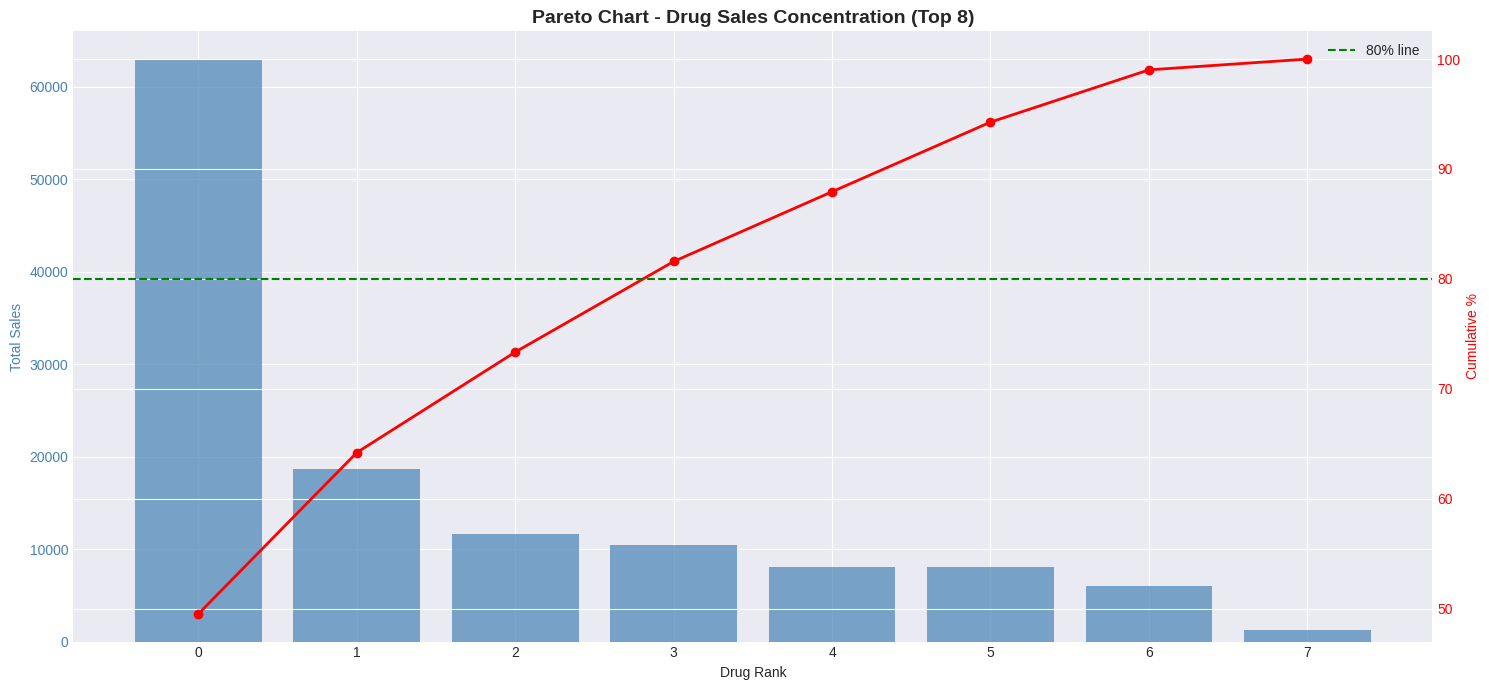

In [35]:
# Market concentration (Pareto principle)
print("=" * 60)
print("MARKET CONCENTRATION ANALYSIS")
print("=" * 60)

drug_sales = df.groupby('drug_name')['total_quantity'].sum().sort_values(ascending=False)
total_sales = drug_sales.sum()
cumulative_sales = drug_sales.cumsum()
cumulative_pct = (cumulative_sales / total_sales) * 100

# How many drugs account for 80% of sales?
drugs_80_pct = (cumulative_pct <= 80).sum()
print(f"Top {drugs_80_pct} drugs account for 80% of total sales")
print(f"That's {drugs_80_pct/len(drug_sales)*100:.1f}% of all drugs")

# Pareto chart
fig, ax1 = plt.subplots(figsize=(15, 7))

top_n = min(30, len(drug_sales))  # Use available drugs if less than 30
ax1.bar(range(top_n), drug_sales.head(top_n).values, color='steelblue', alpha=0.7)
ax1.set_xlabel('Drug Rank')
ax1.set_ylabel('Total Sales', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(range(top_n), cumulative_pct.head(top_n).values, color='red', marker='o', linewidth=2)
ax2.axhline(y=80, color='green', linestyle='--', label='80% line')
ax2.set_ylabel('Cumulative %', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend()

plt.title(f'Pareto Chart - Drug Sales Concentration (Top {top_n})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

MOST VOLATILE DRUGS (Top 10 by Coefficient of Variation)


,mean,std,count,cv
drug_name,,,,
N05C,4.684211,2.905735,266,62.032549
R03,38.423841,22.899299,302,59.596590
R06,19.983444,11.312669,302,56.610205
N02BE,208.142384,76.074646,302,36.549330
N05B,61.692053,22.401824,302,36.312334
N02BA,26.619205,8.070538,302,30.318478
M01AE,26.682119,7.071416,302,26.502454
M01AB,34.635762,8.579883,302,24.771747


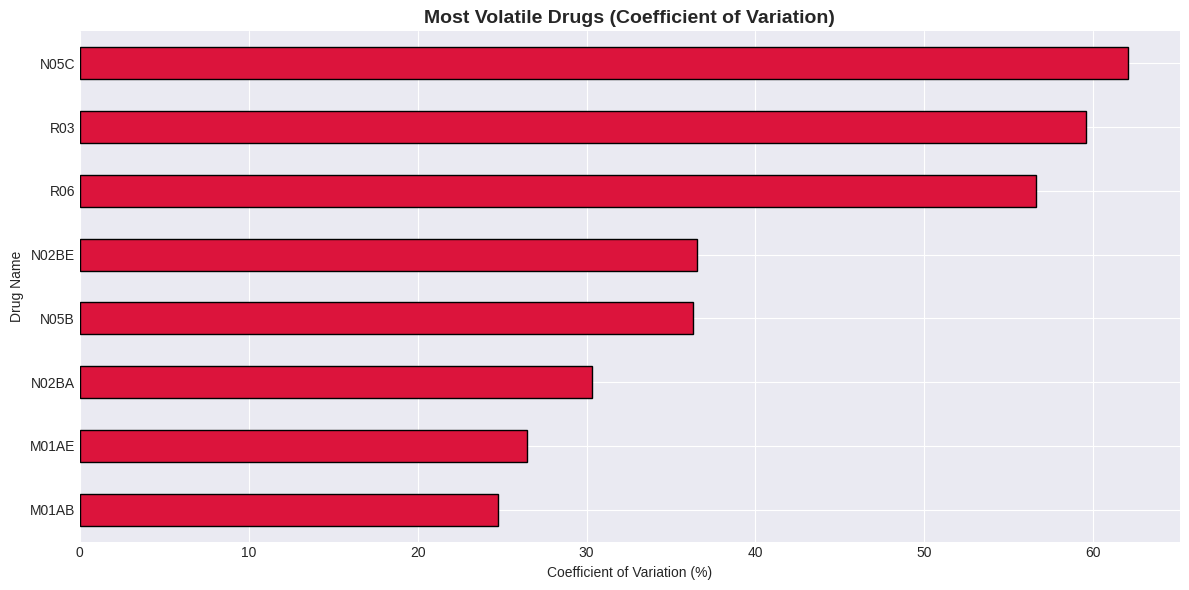

In [32]:
# Sales volatility (drugs with highest variation)
print("=" * 60)
print("MOST VOLATILE DRUGS (Top 10 by Coefficient of Variation)")
print("=" * 60)

volatility = df.groupby('drug_name')['total_quantity'].agg(['mean', 'std', 'count'])
volatility = volatility[volatility['count'] >= 10]  # At least 10 records
volatility['cv'] = (volatility['std'] / volatility['mean']) * 100
volatility = volatility.sort_values('cv', ascending=False).head(10)

display(volatility)

plt.figure(figsize=(12, 6))
volatility['cv'].plot(kind='barh', color='crimson', edgecolor='black')
plt.title('Most Volatile Drugs (Coefficient of Variation)', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient of Variation (%)')
plt.ylabel('Drug Name')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

YEAR-OVER-YEAR GROWTH RATE


,Year,Total Sales,YoY Growth (%)
0,2014,19901,NaN
1,2015,23018,15.662530
2,2016,25027,8.727952
3,2017,19224,-23.186958
4,2018,22685,18.003537
5,2019,17077,-24.721181


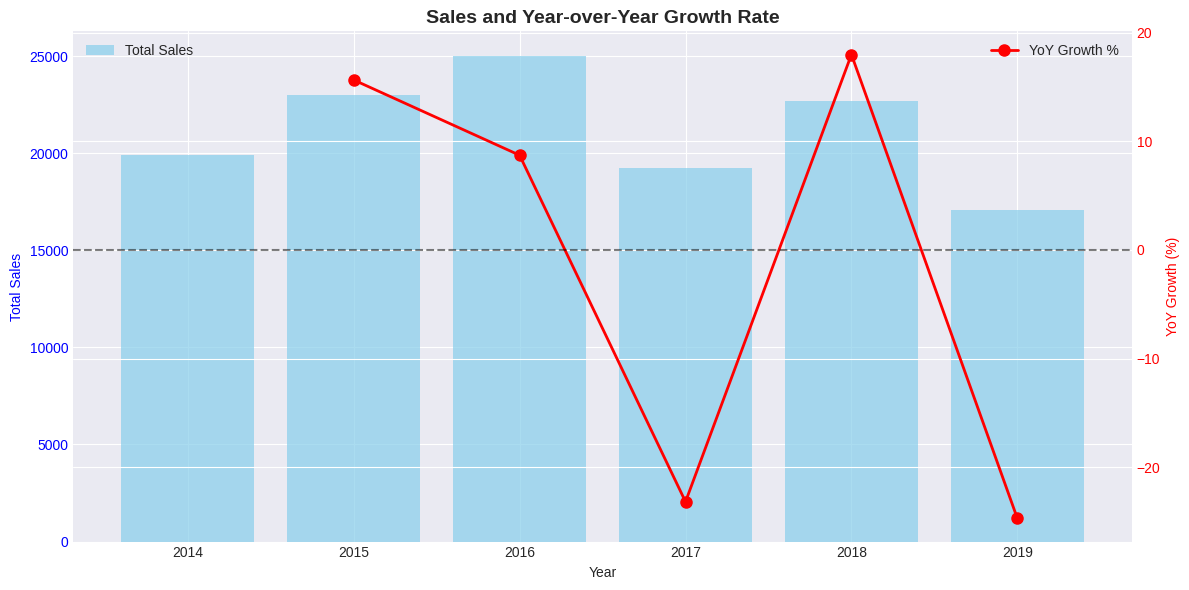

In [33]:
# Growth rate analysis (Year-over-Year)
if df['year'].nunique() > 1:
    print("=" * 60)
    print("YEAR-OVER-YEAR GROWTH RATE")
    print("=" * 60)
    
    yearly_total = df.groupby('year')['total_quantity'].sum().sort_index()
    growth_rate = yearly_total.pct_change() * 100
    
    growth_df = pd.DataFrame({
        'Year': yearly_total.index,
        'Total Sales': yearly_total.values,
        'YoY Growth (%)': growth_rate.values
    })
    
    display(growth_df)
    
    # Visualize
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    ax1.bar(growth_df['Year'], growth_df['Total Sales'], color='skyblue', alpha=0.7, label='Total Sales')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Total Sales', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.legend(loc='upper left')
    
    ax2 = ax1.twinx()
    ax2.plot(growth_df['Year'], growth_df['YoY Growth (%)'], color='red', marker='o', 
             linewidth=2, markersize=8, label='YoY Growth %')
    ax2.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    ax2.set_ylabel('YoY Growth (%)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.legend(loc='upper right')
    
    plt.title('Sales and Year-over-Year Growth Rate', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 10. KEY FINDINGS SUMMARY

In [34]:
print("=" * 60)
print("KEY FINDINGS SUMMARY")
print("=" * 60)

print("\n📊 DATASET OVERVIEW:")
print(f"  • Total records: {len(df):,}")
print(f"  • Unique drugs: {df['drug_name'].nunique()}")
print(f"  • Unique ATC codes: {df['atc_code'].nunique()}")
print(f"  • Date range: {df['week_start_date'].min().date()} to {df['week_start_date'].max().date()}")
print(f"  • Total sales volume: {df['total_quantity'].sum():,.0f}")

print("\n📈 SALES STATISTICS:")
print(f"  • Average weekly sales per drug: {df['total_quantity'].mean():,.2f}")
print(f"  • Median weekly sales per drug: {df['total_quantity'].median():,.2f}")
print(f"  • Standard deviation: {df['total_quantity'].std():,.2f}")
print(f"  • Min sales: {df['total_quantity'].min():,.0f}")
print(f"  • Max sales: {df['total_quantity'].max():,.0f}")

print("\n🏆 TOP PERFORMERS:")
top_3 = df.groupby('drug_name')['total_quantity'].sum().nlargest(3)
for i, (drug, sales) in enumerate(top_3.items(), 1):
    print(f"  {i}. {drug}: {sales:,.0f}")

print("\n⚠️ DATA QUALITY:")
print(f"  • Missing values: {df.isnull().sum().sum()}")
print(f"  • Duplicate rows: {df.duplicated().sum()}")
print(f"  • Zero quantities: {(df['total_quantity'] == 0).sum()}")
print(f"  • Outliers (IQR method): {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")

print("\n💡 INSIGHTS:")
print(f"  • Market concentration: Top {drugs_80_pct} drugs account for 80% of sales")
print(f"  • Distribution skewness: {df['total_quantity'].skew():.2f} {'(right-skewed)' if df['total_quantity'].skew() > 0 else '(left-skewed)'}")

if df['year'].nunique() > 1:
    latest_year = df['year'].max()
    previous_year = latest_year - 1
    if previous_year in df['year'].values:
        latest_sales = df[df['year'] == latest_year]['total_quantity'].sum()
        previous_sales = df[df['year'] == previous_year]['total_quantity'].sum()
        growth = ((latest_sales - previous_sales) / previous_sales) * 100
        print(f"  • YoY growth ({previous_year} to {latest_year}): {growth:+.2f}%")

print("\n" + "=" * 60)

KEY FINDINGS SUMMARY

📊 DATASET OVERVIEW:
  • Total records: 2,380
  • Unique drugs: 8
  • Unique ATC codes: 8
  • Date range: 2013-12-30 to 2019-10-07
  • Total sales volume: 126,932

📈 SALES STATISTICS:
  • Average weekly sales per drug: 53.33
  • Median weekly sales per drug: 31.00
  • Standard deviation: 67.92
  • Min sales: 1
  • Max sales: 546

🏆 TOP PERFORMERS:
  1. N02BE: 62,859
  2. N05B: 18,631
  3. R03: 11,604

⚠️ DATA QUALITY:
  • Missing values: 0
  • Duplicate rows: 0
  • Zero quantities: 0
  • Outliers (IQR method): 321 (13.49%)

💡 INSIGHTS:
  • Market concentration: Top 3 drugs account for 80% of sales
  • Distribution skewness: 2.66 (right-skewed)
  • YoY growth (2018 to 2019): -24.72%



## 11. NEXT STEPS & RECOMMENDATIONS

Based on the EDA findings, here are recommended next steps:

### Data Quality:
- [ ] Investigate and handle outliers (business rules vs. data errors)
- [ ] Address any missing weeks in the time series
- [ ] Validate zero quantity records

### Feature Engineering:
- [ ] Create lag features (previous week sales, moving averages)
- [ ] Add seasonal indicators (month, quarter, holiday flags)
- [ ] Calculate rolling statistics (7-day, 30-day averages)
- [ ] Create drug category groupings based on ATC codes

### Further Analysis:
- [ ] Demand forecasting models (ARIMA, Prophet, LSTM)
- [ ] Clustering analysis (group similar drugs)
- [ ] Anomaly detection (unusual sales patterns)
- [ ] Basket analysis (drugs purchased together)

### Business Applications:
- [ ] Inventory optimization
- [ ] Demand planning
- [ ] Marketing campaign targeting
- [ ] Supply chain optimization

---

## End of EDA Report

**Generated on:** $(date)

**Next:** Save key findings and proceed to modeling phase